<!-- parity-note -->
## MATLAB Parity Note
- Source MATLAB helpfile: `PPSimExample.mlx`
- Fidelity status: `exact`
- Remaining justified differences: Follows the MATLAB recursive-CIF workflow with the native Python `CIF.simulateCIF` path and all 9 published figures. Only inherent Simulink vs Python solver timing and stochastic draws differ.

Suggested Actions:
    • Specify an integer multiple of the fixed step size for the stop time of the simulation. - Fix
    • Set Automatic solver parameter selection diagnostic to 'none'. - Apply

Suggested Actions:
    • Specify an integer multiple of the fixed step size for the stop time of the simulation. - Fix
    • Set Automatic solver parameter selection diagnostic to 'none'. - Apply

Suggested Actions:
    • Specify an integer multiple of the fixed step size for the stop time of the simulation. - Fix
    • Set Automatic solver parameter selection diagnostic to 'none'. - Apply

Suggested Actions:
    • Specify an integer multiple of the fixed step size for the stop time of the simulation. - Fix
    • Set Automatic solver parameter selection diagnostic to 'none'. - Apply

Suggested Actions:
    • Specify an integer multiple of the fixed step size for the stop time of the simulation. - Fix
    • Set Automatic solver parameter selection diagnostic to 'none'. - Apply

{'duration_s': 

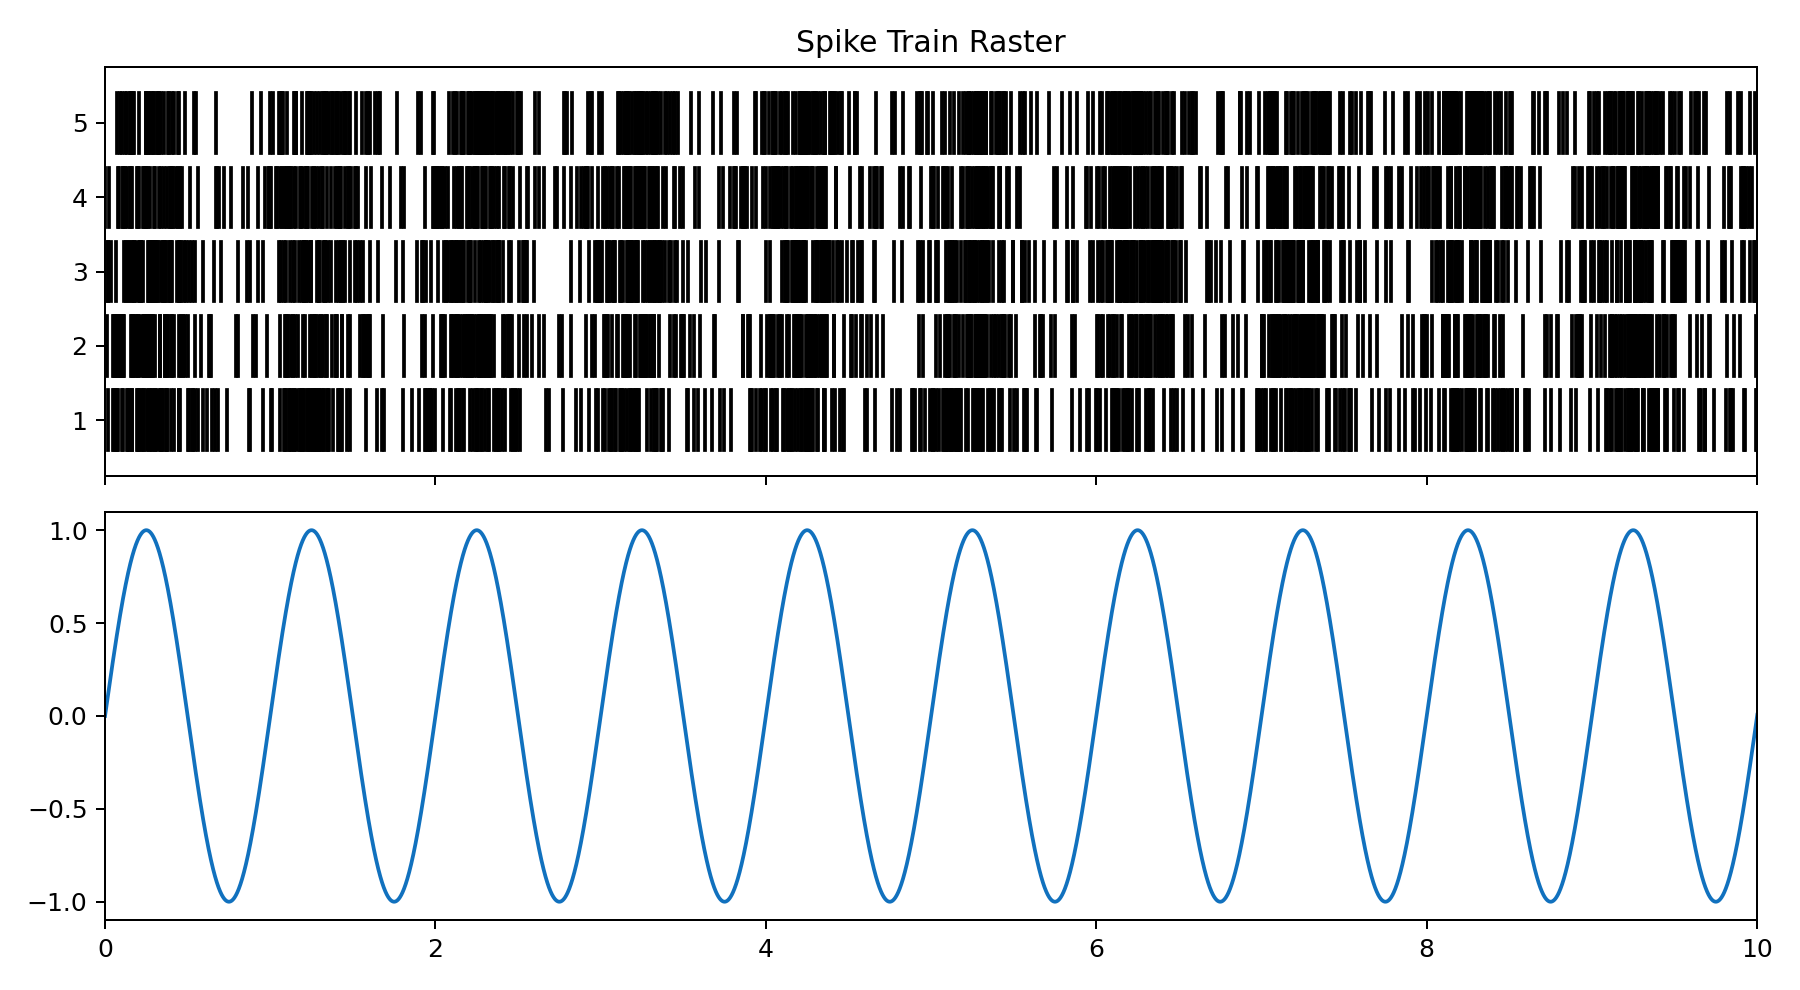

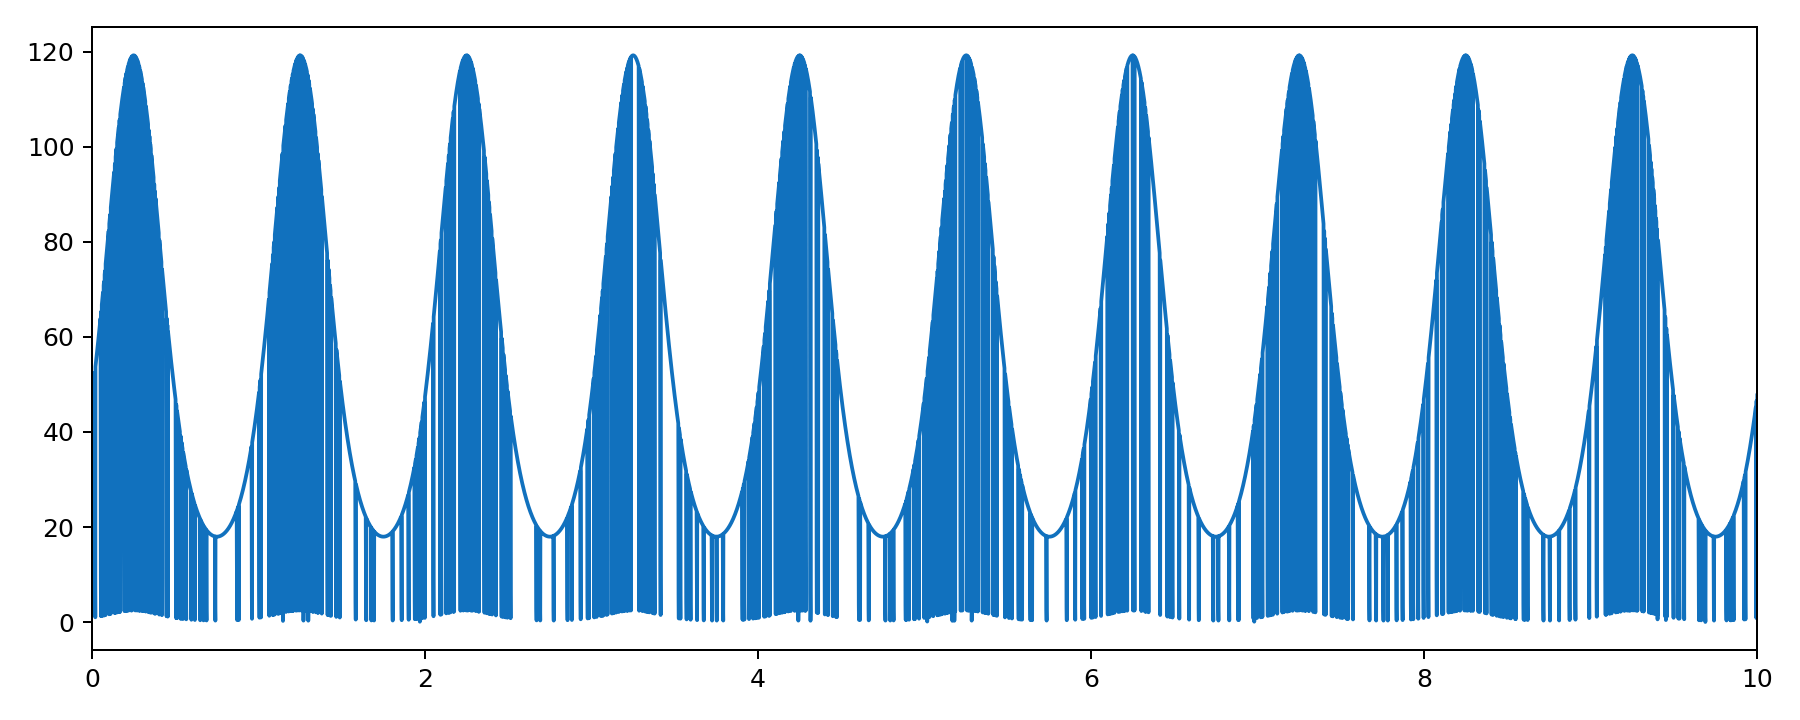

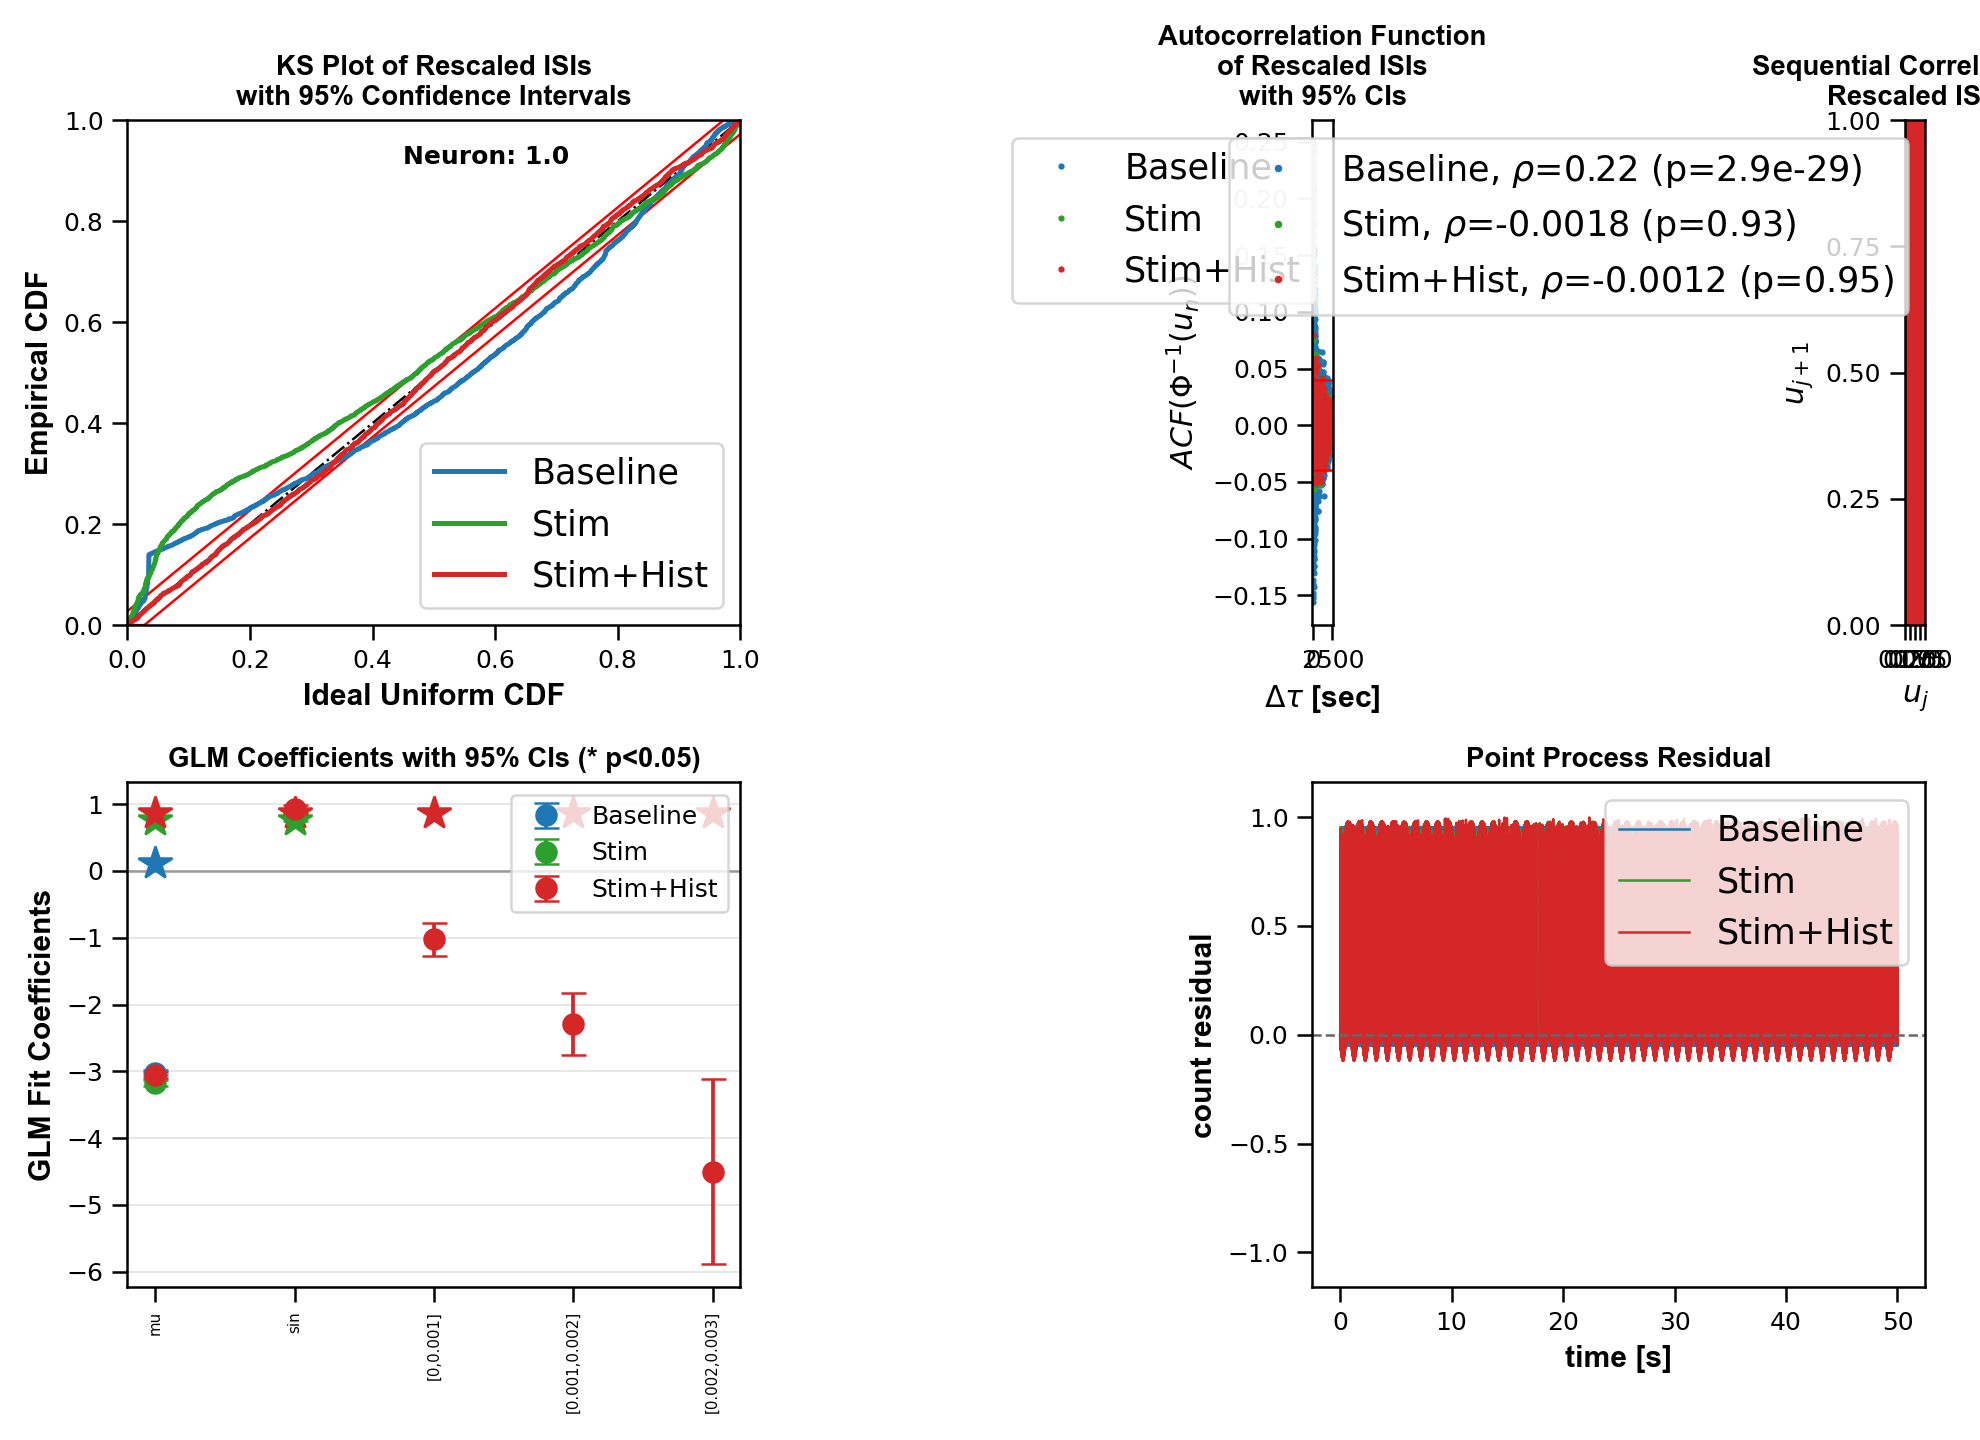

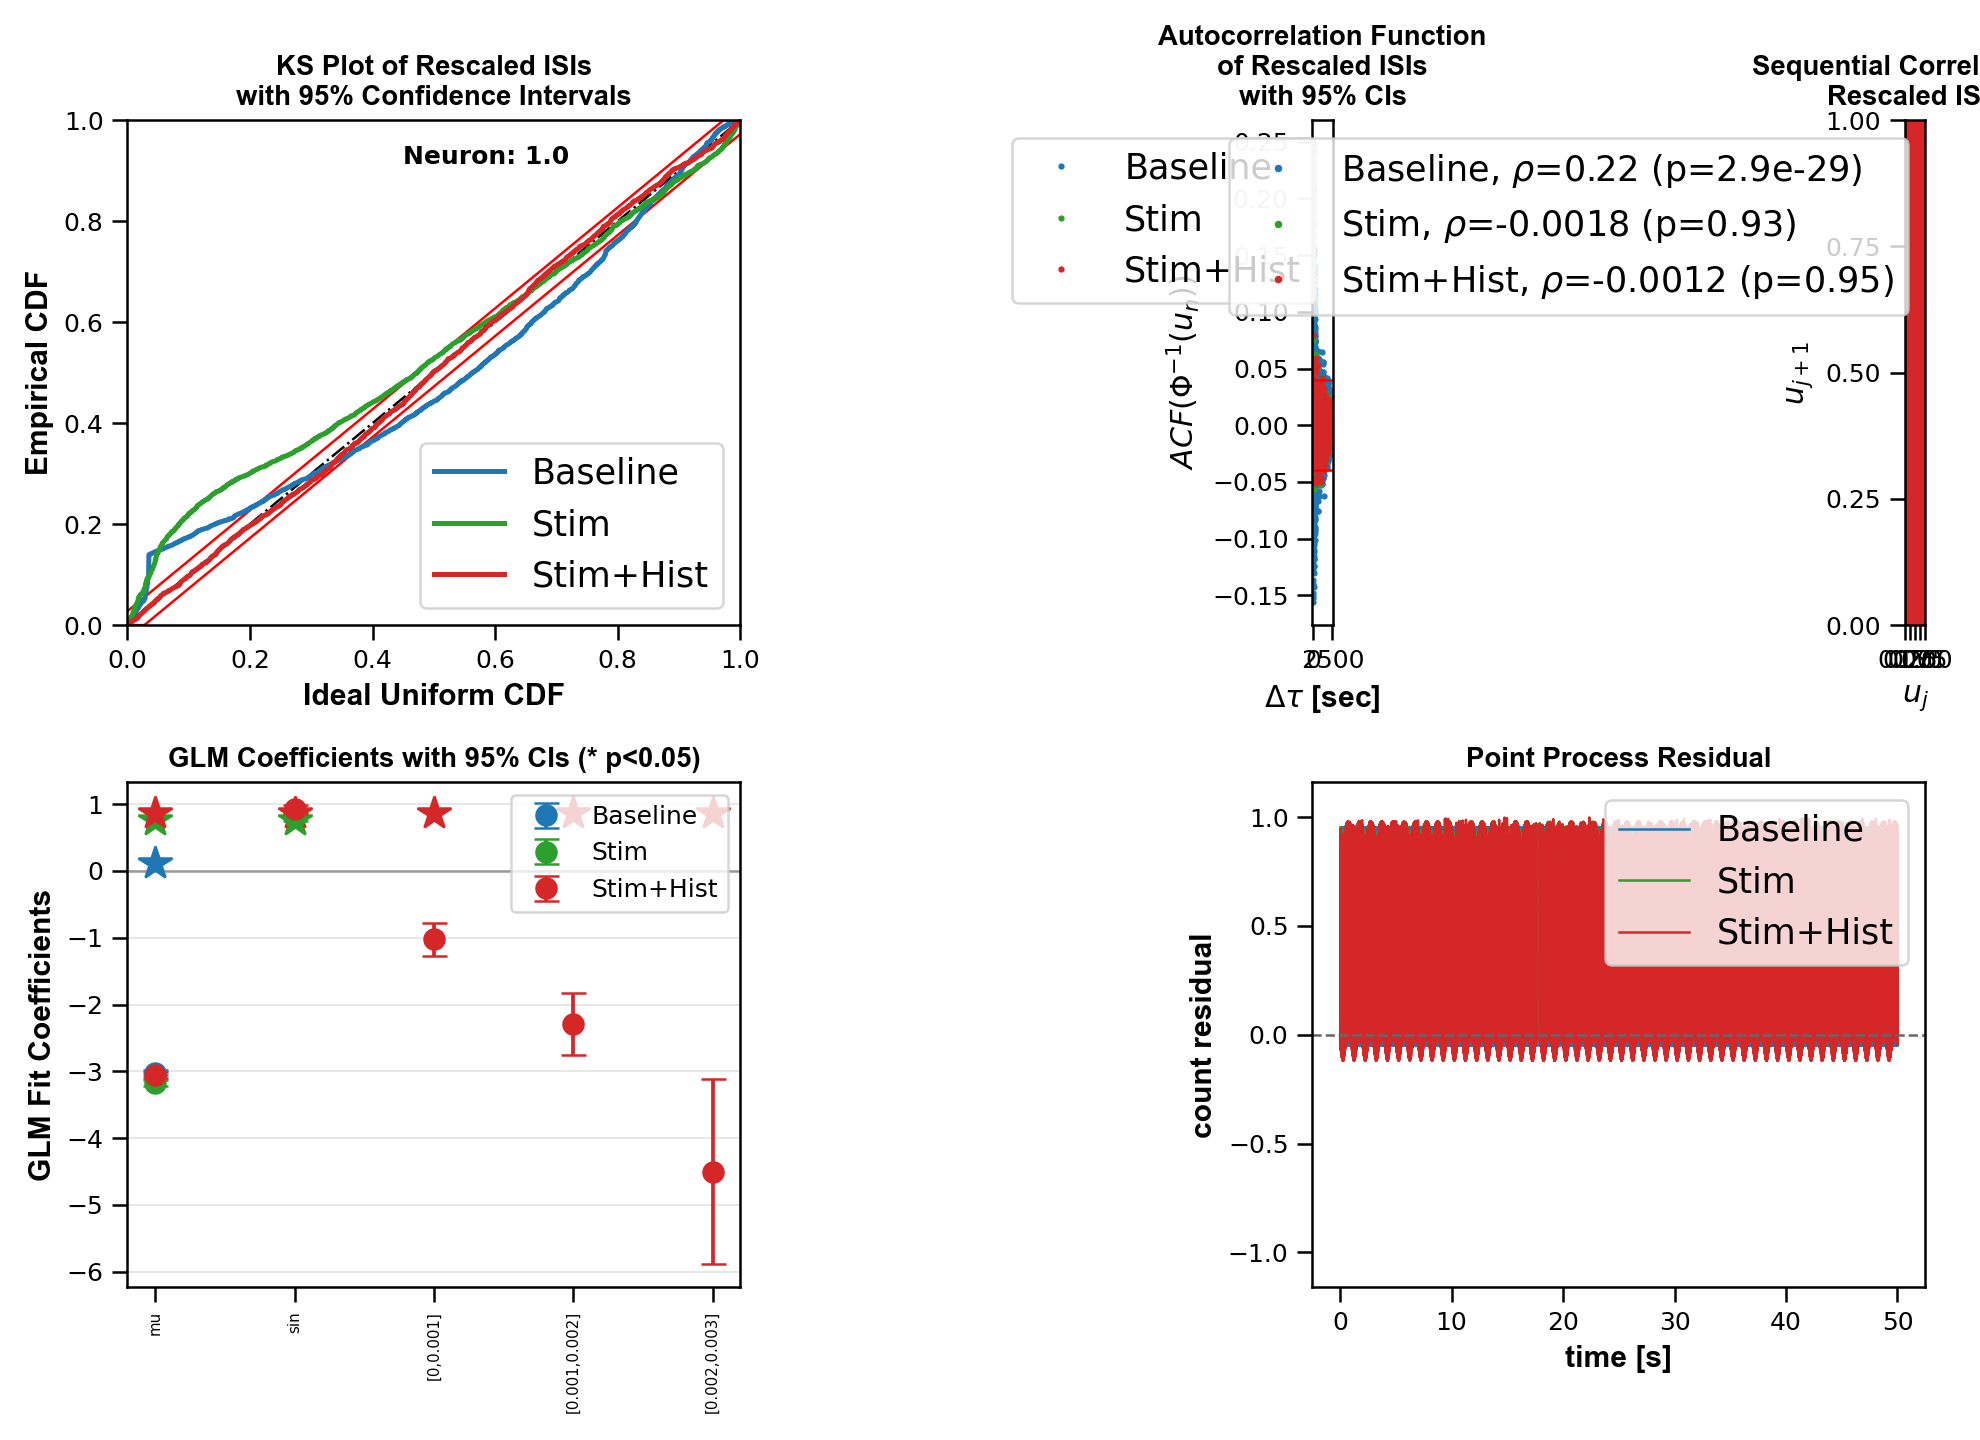

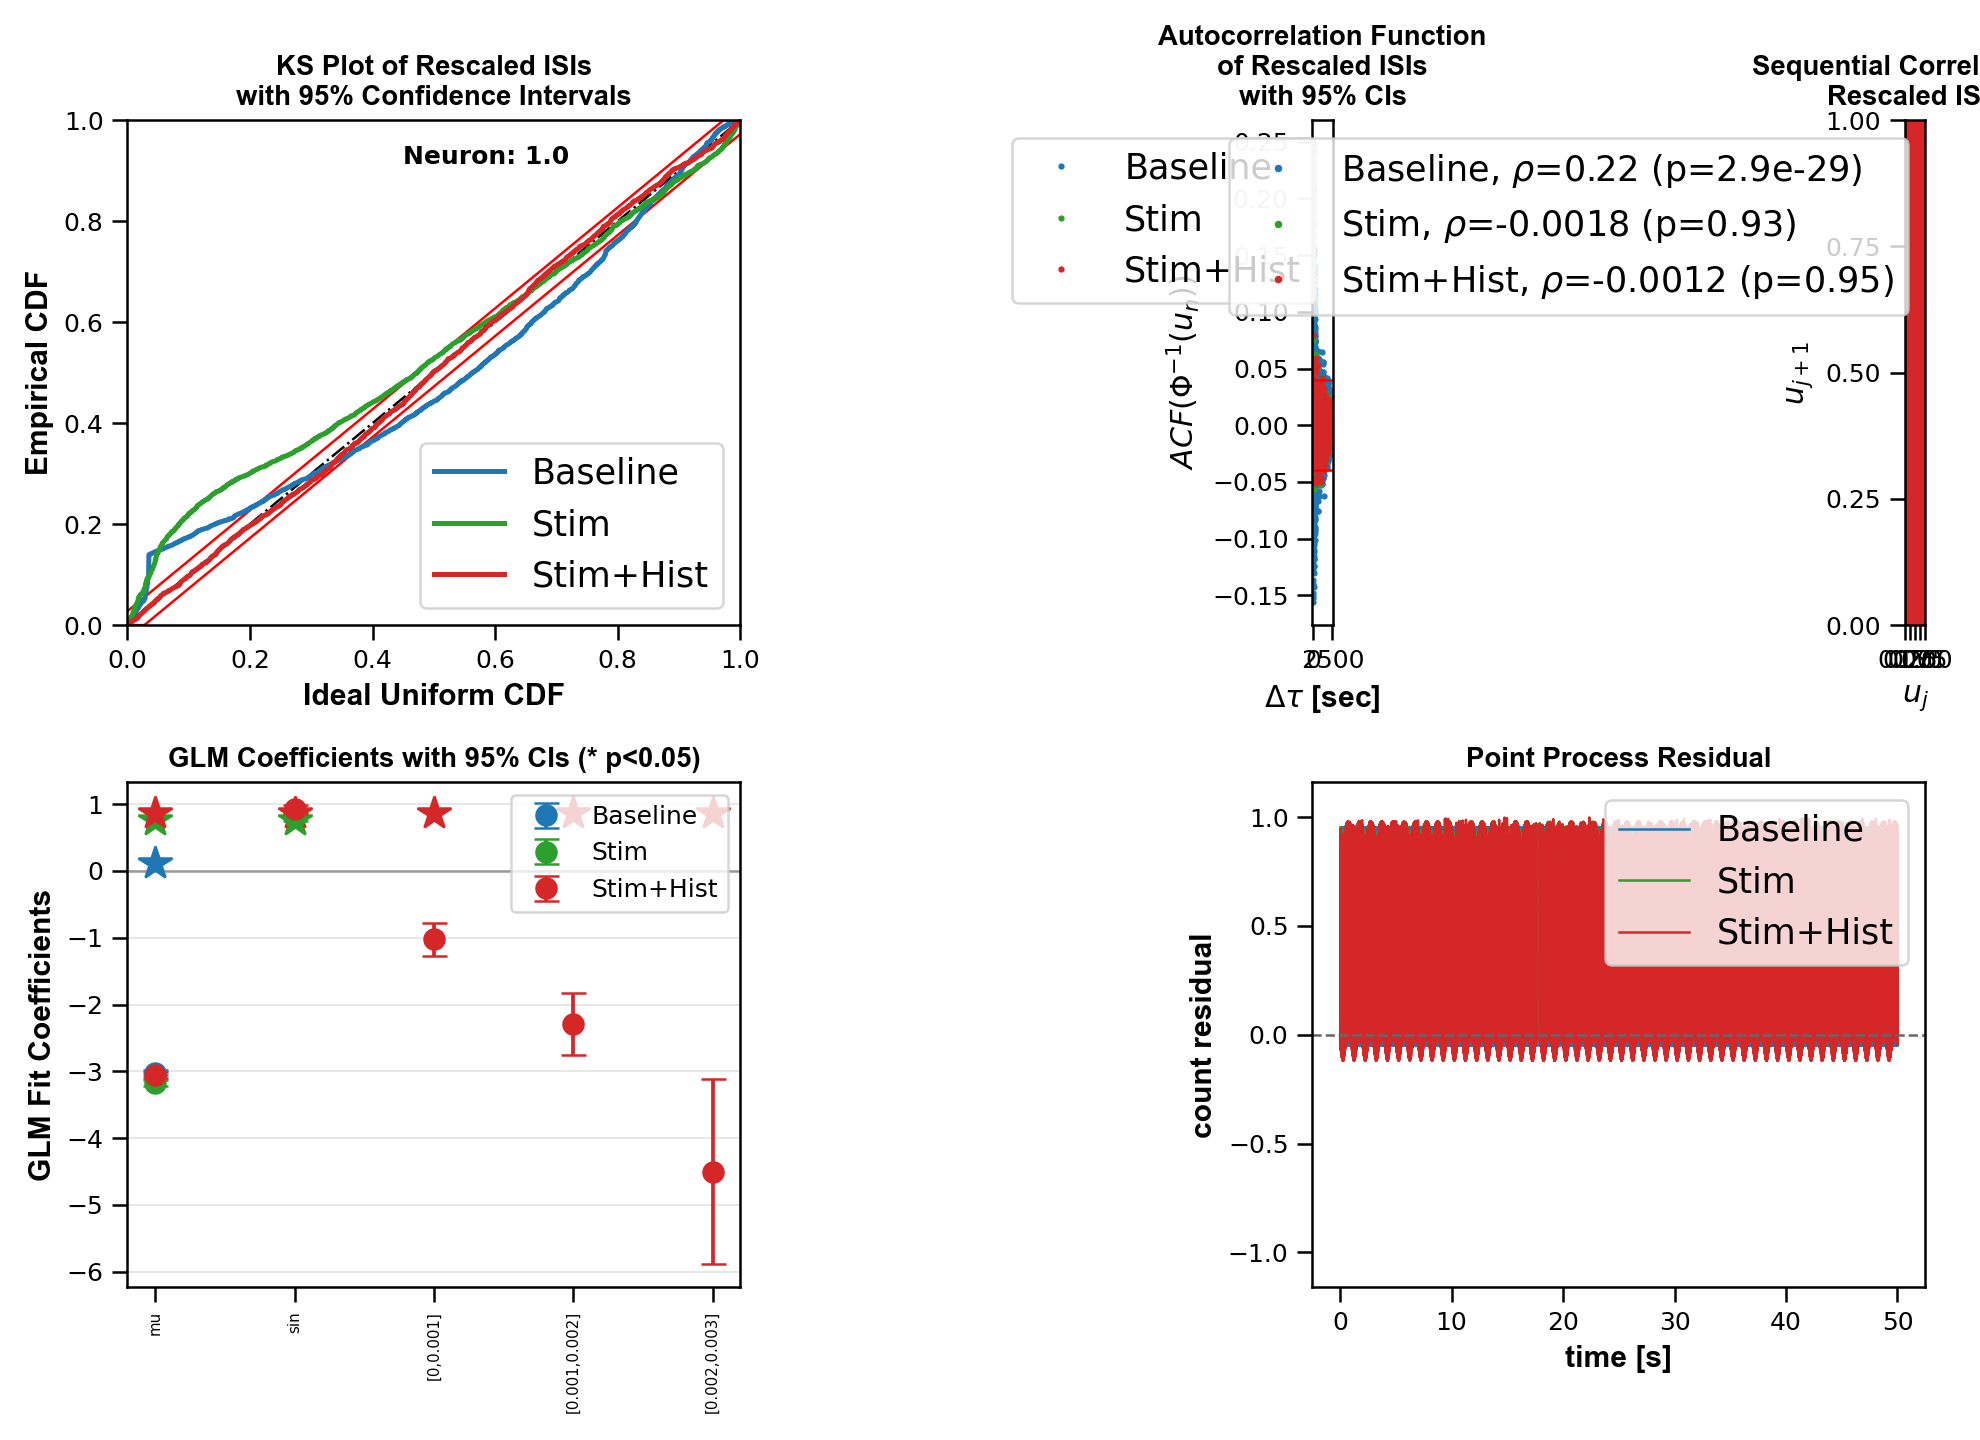

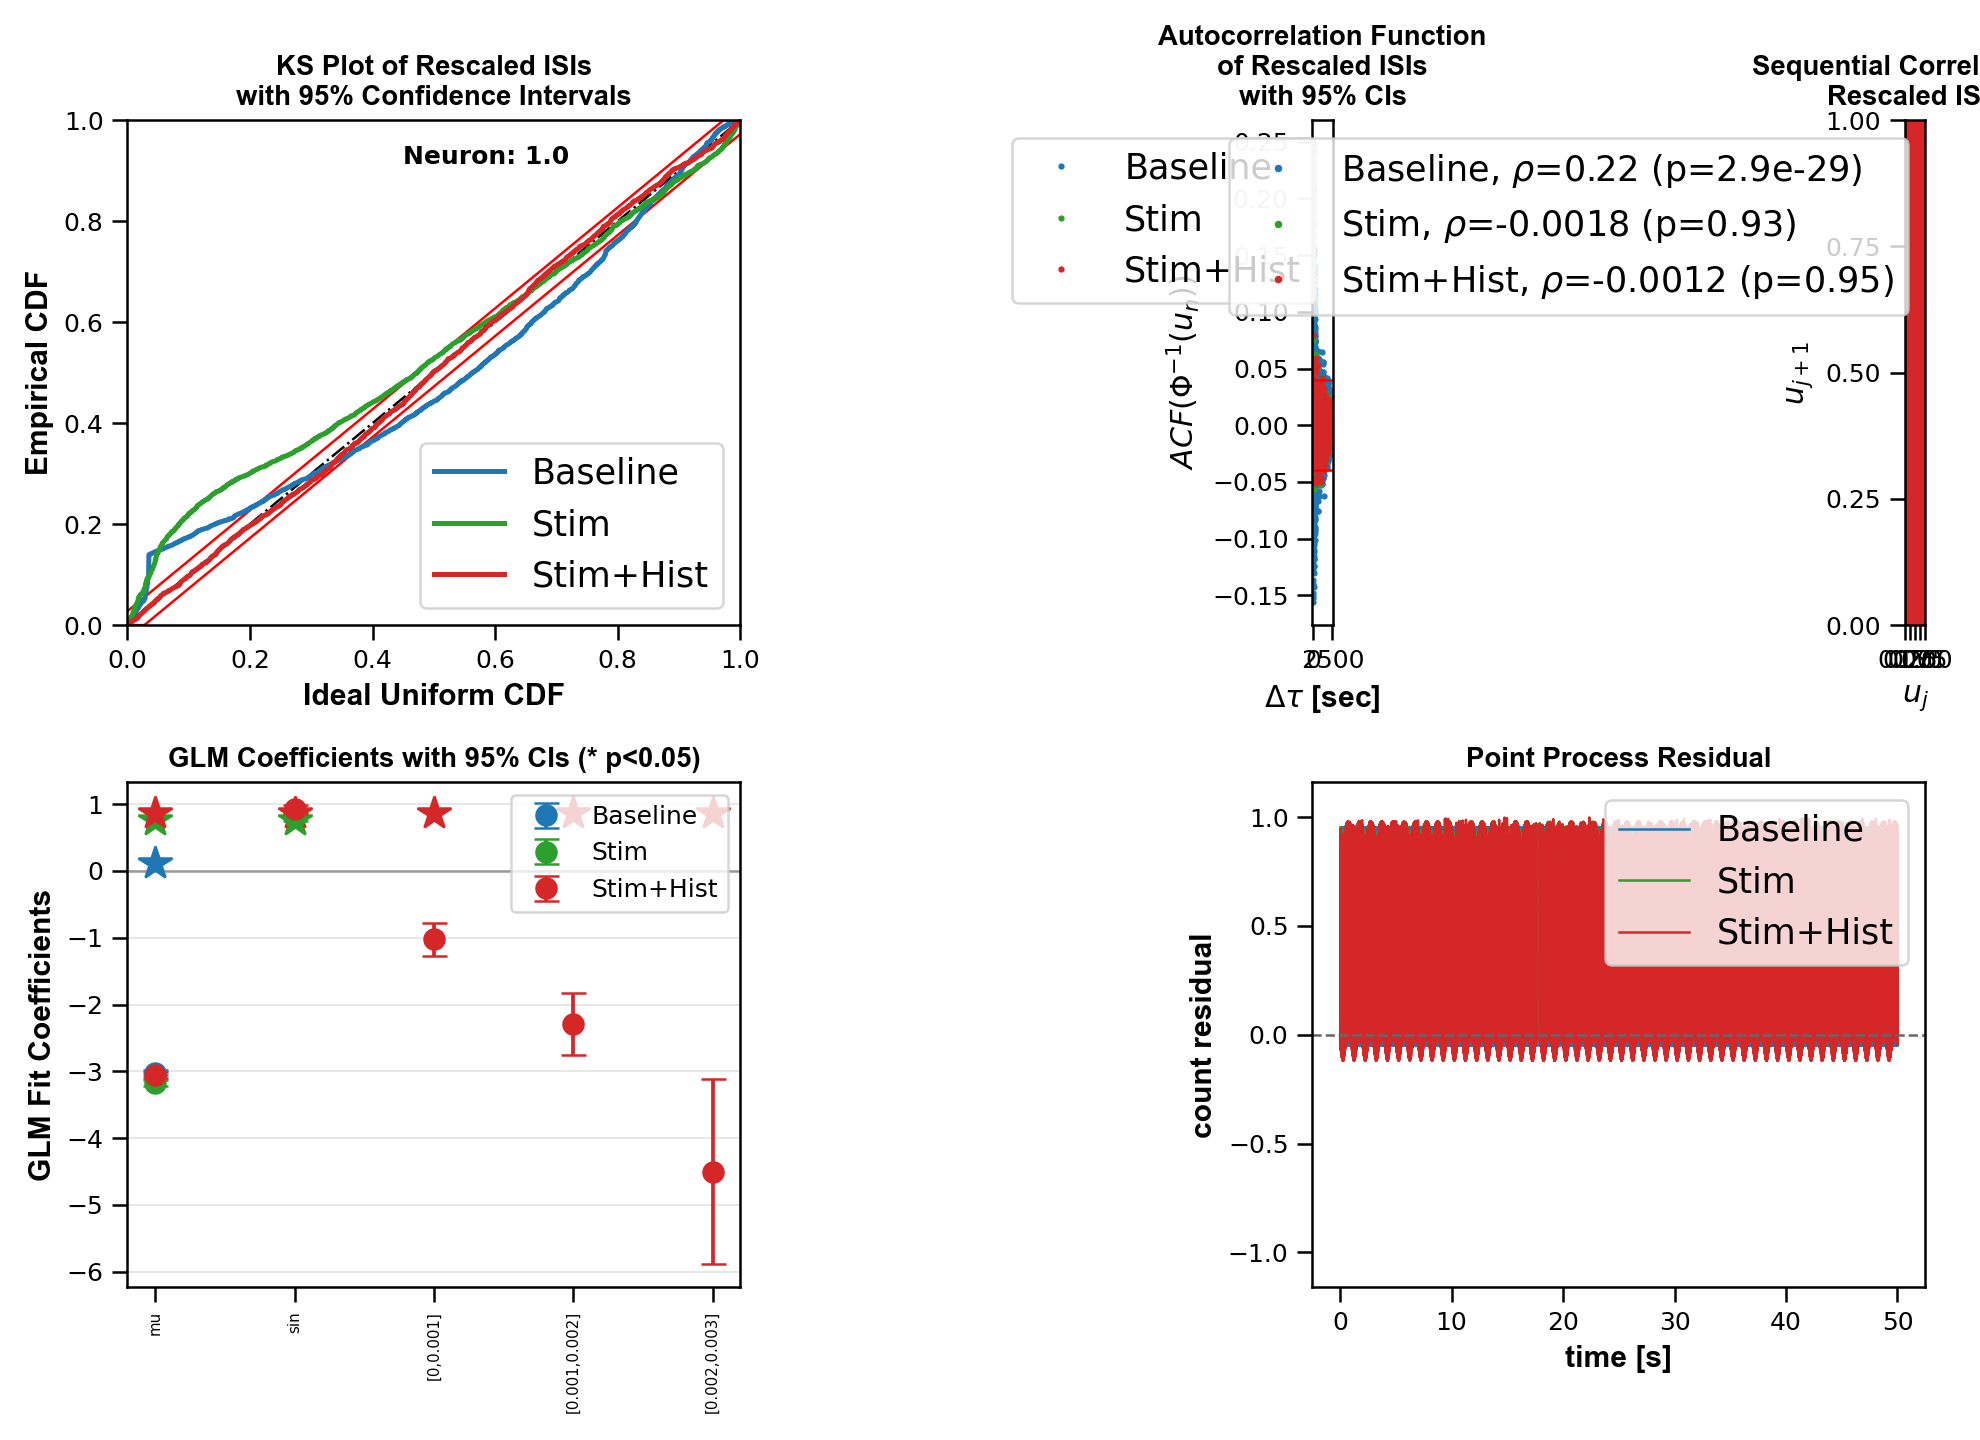

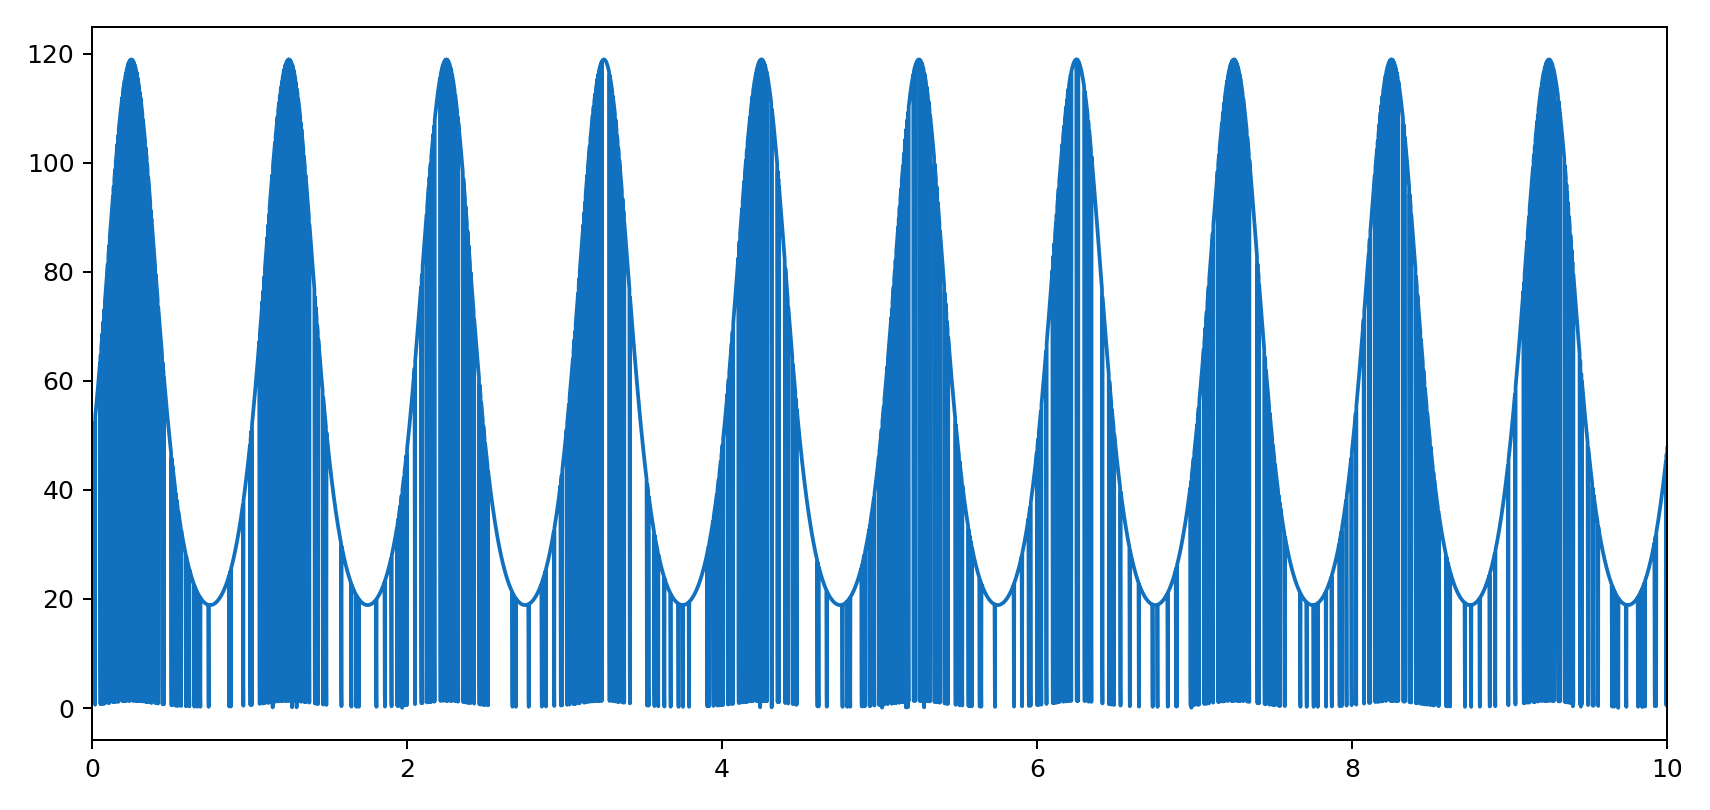

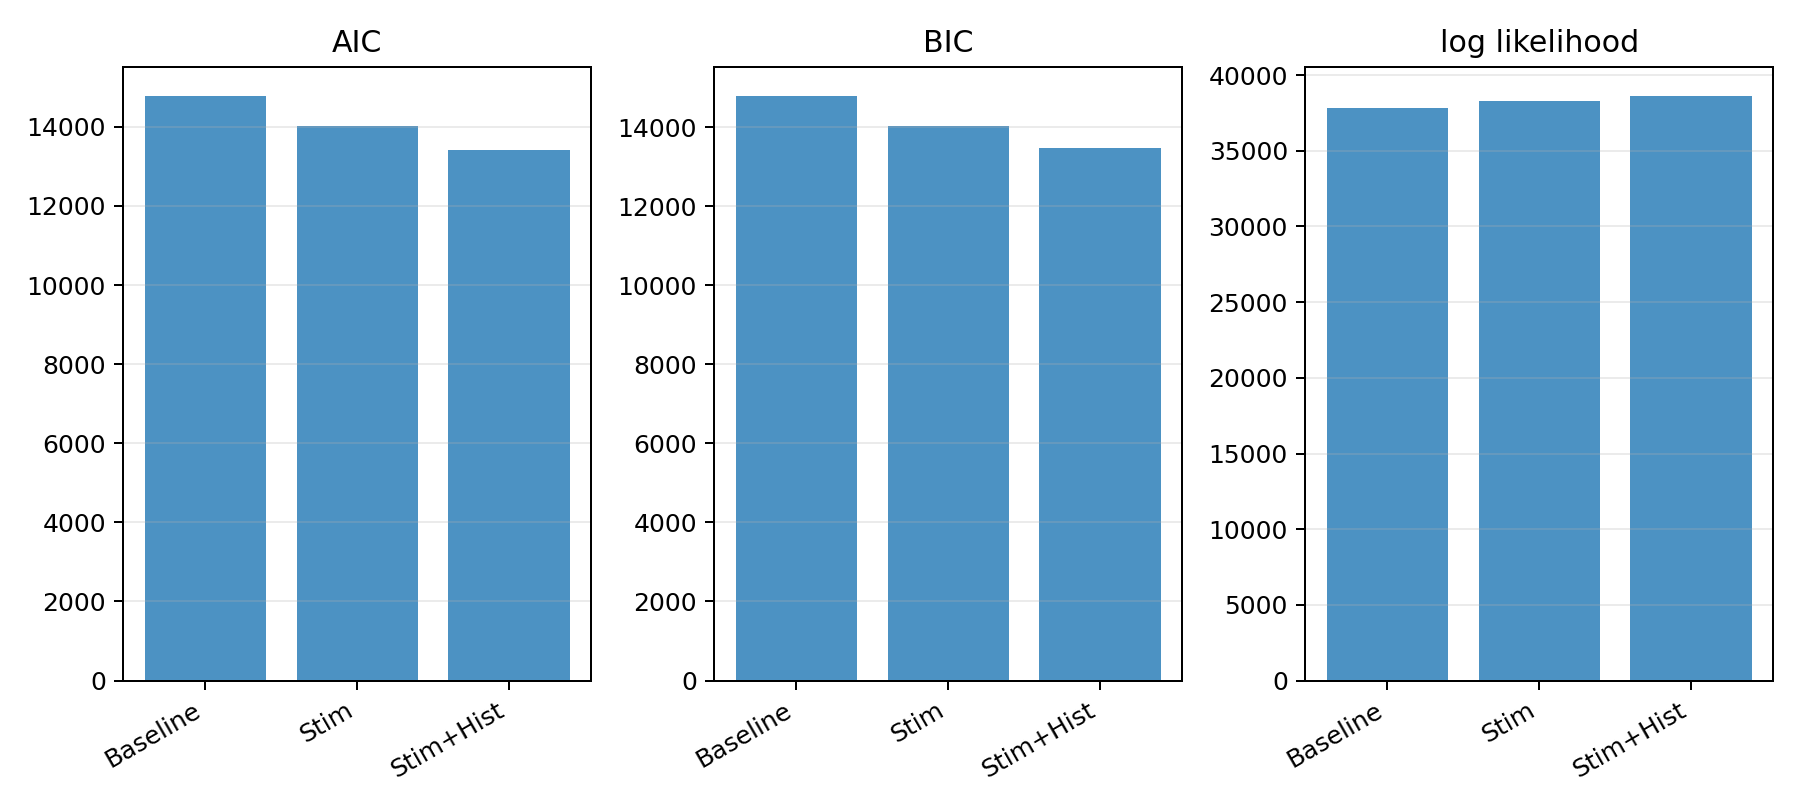

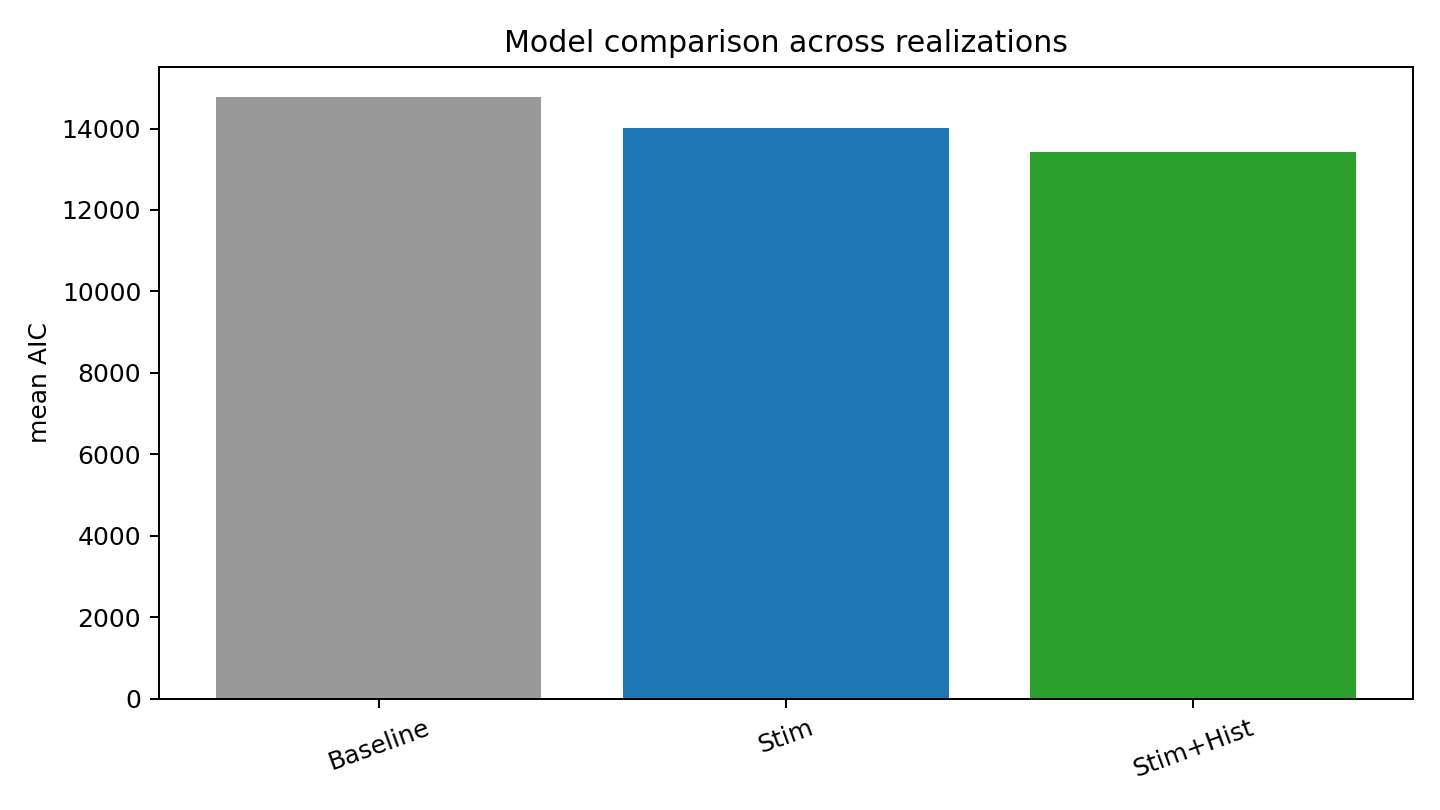

In [1]:
# nSTAT-python notebook example: PPSimExample
from pathlib import Path
import sys

REPO_ROOT = Path.cwd().resolve().parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))
SRC_PATH = (REPO_ROOT / "src").resolve()
if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np

from nstat import Analysis, CIF, ConfigColl, CovColl, Covariate, FitResSummary, Trial, TrialConfig
from nstat.notebook_figures import FigureTracker

np.random.seed(5)
OUTPUT_ROOT = REPO_ROOT / "output" / "notebook_images"
__tracker = FigureTracker(topic='PPSimExample', output_root=OUTPUT_ROOT, expected_count=9)

def _figure(label: str, *, figsize=(8.5, 4.5)):
    fig = __tracker.new_figure(label)
    fig.clear()
    fig.set_size_inches(*figsize)
    return fig

Ts = 0.001
tMin = 0.0
tMax = 50.0
t = np.arange(tMin, tMax + Ts, Ts)
mu = -3.0
H = np.array([-1.0, -2.0, -4.0], dtype=float)
S = np.array([1.0], dtype=float)
E = np.array([0.0], dtype=float)
stimulus_signal = np.sin(2 * np.pi * 1.0 * t)
stim = Covariate(t, stimulus_signal, "Stimulus", "time", "s", "Voltage", ["sin"])
ens = Covariate(t, np.zeros_like(t), "Ensemble", "time", "s", "Spikes", ["n1"])
baseline = Covariate(t, np.ones_like(t), "Baseline", "time", "s", "", ["mu"])
sC, lambda_cov = CIF.simulateCIF(mu, H, S, E, stim, ens, 5, "binomial", seed=5, return_lambda=True)
cc = CovColl([stim, baseline])
trial = Trial(sC, cc)
print({"duration_s": tMax, "num_realizations": sC.numSpikeTrains, "mean_rate_hz": round(float(np.mean(lambda_cov.data[:, 0])), 3)})

In [2]:
# SECTION 1: General Point Process Simulation
plt.close("all")

In [3]:
# SECTION 2: Point Process Sample Path Generation
print("Using native Python CIF.simulateCIF to mirror the MATLAB recursive-CIF workflow.")

Using native Python CIF.simulateCIF to mirror the MATLAB recursive-CIF workflow.


In [4]:
# SECTION 3: History Effect
selfHist = [0.0, 0.001, 0.002, 0.003]
print({"history_windows_s": selfHist})

{'history_windows_s': [0.0, 0.001, 0.002, 0.003]}


In [5]:
# SECTION 4: Stimulus Effect
print({"stimulus_frequency_hz": 1.0, "stimulus_amplitude": 1.0})

{'stimulus_frequency_hz': 1.0, 'stimulus_amplitude': 1.0}


In [6]:
# SECTION 5: Ensemble Effect
print({"ensemble_effect": 0.0})

{'ensemble_effect': 0.0}


In [7]:
# SECTION 6: Generate sample paths
fig = _figure("figure; subplot(2,1,1); sC.plot; subplot(2,1,2); stim.plot", figsize=(10.0, 5.5))
axs = fig.subplots(2, 1, sharex=True)
sC.plot(handle=axs[0])
axs[0].set_xlim(0.0, tMax / 5.0)
stim.plot(handle=axs[1])
axs[1].set_xlim(0.0, tMax / 5.0)

(0.0, 10.0)

In [8]:
# SECTION 7: Inspect the simulated CIF
fig = _figure("figure; lambda.plot", figsize=(10.0, 4.0))
ax = fig.subplots(1, 1)
lambda_cov.getSubSignal(0).plot(handle=ax)
ax.set_xlim(0.0, tMax / 5.0)

(0.0, 10.0)

In [9]:
# SECTION 8: GLM Model Fitting Setup
cfg = [
    TrialConfig([["Baseline", "mu"]], sampleRate=1.0 / Ts, name="Baseline"),
    TrialConfig([["Baseline", "mu"], ["Stimulus", "sin"]], sampleRate=1.0 / Ts, name="Stim"),
    TrialConfig([["Baseline", "mu"], ["Stimulus", "sin"]], sampleRate=1.0 / Ts, history=selfHist, name="Stim+Hist"),
]
cfgColl = ConfigColl(cfg)

In [10]:
# SECTION 9: Choose the MATLAB-style fitting algorithm
Algorithm = "BNLRCG"
print({"algorithm": Algorithm, "binary_representation": bool(sC.getNST(0).isSigRepBinary())})

{'algorithm': 'BNLRCG', 'binary_representation': True}


In [11]:
# SECTION 10: GLM Model Fitting and Results
results = Analysis.RunAnalysisForAllNeurons(trial, cfgColl)

In [12]:
# SECTION 11: Results for sample neuron
fig = _figure("results{1}.plotResults", figsize=(11.0, 8.0))
results[0].plotResults(handle=fig)

<Figure size 1100x800 with 5 Axes>

In [13]:
# SECTION 12: Baseline-only diagnostic view
fig = _figure("results{1}.plotResults baseline", figsize=(11.0, 8.0))
results[0].plotResults(fit_num=0, handle=fig)

<Figure size 1100x800 with 5 Axes>

In [14]:
# SECTION 13: Stimulus model diagnostic view
fig = _figure("results{2}.plotResults stim", figsize=(11.0, 8.0))
results[0].plotResults(fit_num=1, handle=fig)

<Figure size 1100x800 with 5 Axes>

In [15]:
# SECTION 14: Stimulus-plus-history diagnostic view
fig = _figure("results{3}.plotResults hist", figsize=(11.0, 8.0))
results[0].plotResults(fit_num=2, handle=fig)

<Figure size 1100x800 with 5 Axes>

In [16]:
# SECTION 15: Compare fitted firing rates
fig = _figure("results.lambda.plot", figsize=(9.5, 4.5))
ax = fig.subplots(1, 1)
results[0].lambdaSignal.getSubSignal(2).plot(handle=ax)
ax.set_xlim(0.0, tMax / 5.0)

(0.0, 10.0)

In [17]:
# SECTION 16: Results across all sample paths
summary = FitResSummary(results)
fig = _figure("Summary.plotSummary", figsize=(10.0, 4.5))
summary.plotSummary(handle=fig)
print({"fit_names": summary.fitNames, "mean_AIC": np.asarray(summary.meanAIC, dtype=float).round(3).tolist()})

{'fit_names': ['Baseline', 'Stim', 'Stim+Hist'], 'mean_AIC': [14768.013, 14013.036, 13415.194]}


In [18]:
# SECTION 17: Summarize model selection
fig = _figure("bar(summary.AIC)", figsize=(8.0, 4.5))
ax = fig.subplots(1, 1)
ax.bar(np.arange(len(summary.fitNames)), np.asarray(summary.meanAIC, dtype=float), color=["0.6", "tab:blue", "tab:green"])
ax.set_xticks(np.arange(len(summary.fitNames)), summary.fitNames, rotation=20)
ax.set_ylabel("mean AIC")
ax.set_title("Model comparison across realizations")
__tracker.finalize()